In [1]:
import xarray as xr
import json

import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import dpa_ensemble as de
import utils as ut
import evaluation
import pandas as pd
import torch
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [2]:
# Factual
# load true test data
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
### Load temperature data ###
ds_test_eth_fact = xr.open_dataset(settings['dataset_trefht_eth_transient'])
ds_test_eth_fact

# load DPA ensemble
dpa_eth_fact = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v4_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128_bnisTrue/dpa_ensemble_after_20_epochs/eth_ensemble_after_20_epochs/ETH_gen_dpa_ens_20_dataset_restored.nc")
dpa_eth_fact

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB ...

In [3]:
# Counterfactual
# load true test data
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
### Load temperature data ###
ds_test_eth_cf = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf

# load DPA ensemble
dpa_eth_cf = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v4_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128_bnisTrue/dpa_ensemble_after_20_epochs/eth_ensemble_after_20_epochs/ETH_cf_gen_dpa_ens_20_dataset_restored.nc")
dpa_eth_cf

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB ...

In [4]:
# compute domain average temperature
dpa_eth_ens_spatial_mean = dpa_eth_fact.TREFHT.mean(dim=("lat","lon"))
dpa_eth_ens_spatial_mean_cf = dpa_eth_cf.TREFHT.mean(dim=("lat","lon"))


dpa_eth_ens_spatial_mean

fact_dpa_mean = dpa_eth_fact.TREFHT.mean(dim="ensemble_member")
fact_dpa_mean

cf_dpa_mean = dpa_eth_cf.TREFHT.mean(dim="ensemble_member")

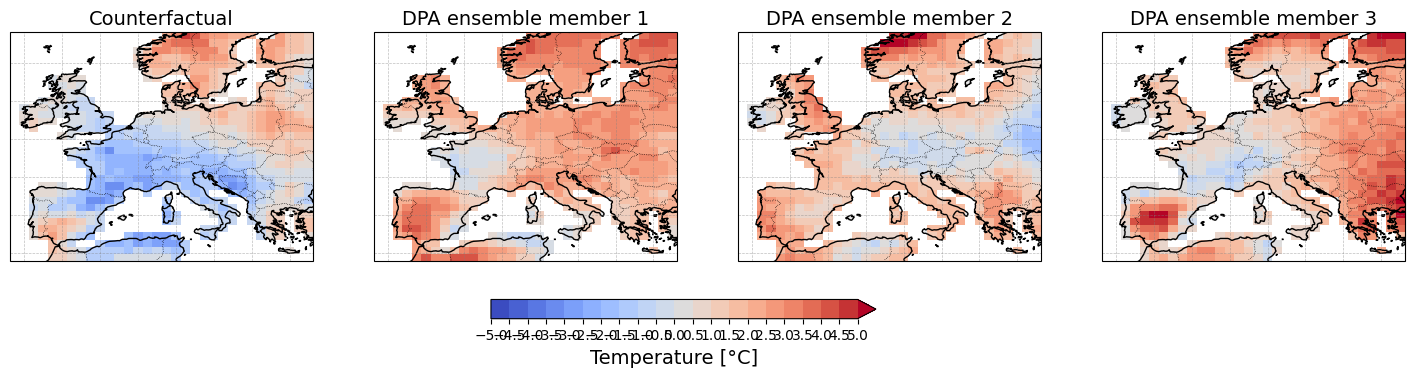

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Example dataset: ds.TREFHT should exist
date = 3050

# Fields for illustration
field_factual = ds_test_eth_cf.TREFHT.isel(time=date)
field_1 = dpa_eth_cf.TREFHT.isel(ensemble_member = 0, time=date)
field_2 = dpa_eth_cf.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_cf.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-5,5,21)
cmap = "coolwarm"

# Create figure and subplots
fig, axes = plt.subplots(
    1, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(18, 5)
)

titles = ["Counterfactual", "DPA ensemble member 1", "DPA ensemble member 2", "DPA ensemble member 3"]
fields = [field_factual, field_1, field_2, field_3]

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=14)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Temperature [°C]', fontsize=14)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
plt.savefig("cf_dpa_sample.pdf")
plt.show()


## Maps

2040-07-22 00:00:00


Text(-0.125, 0.5, 'Counterfactual')

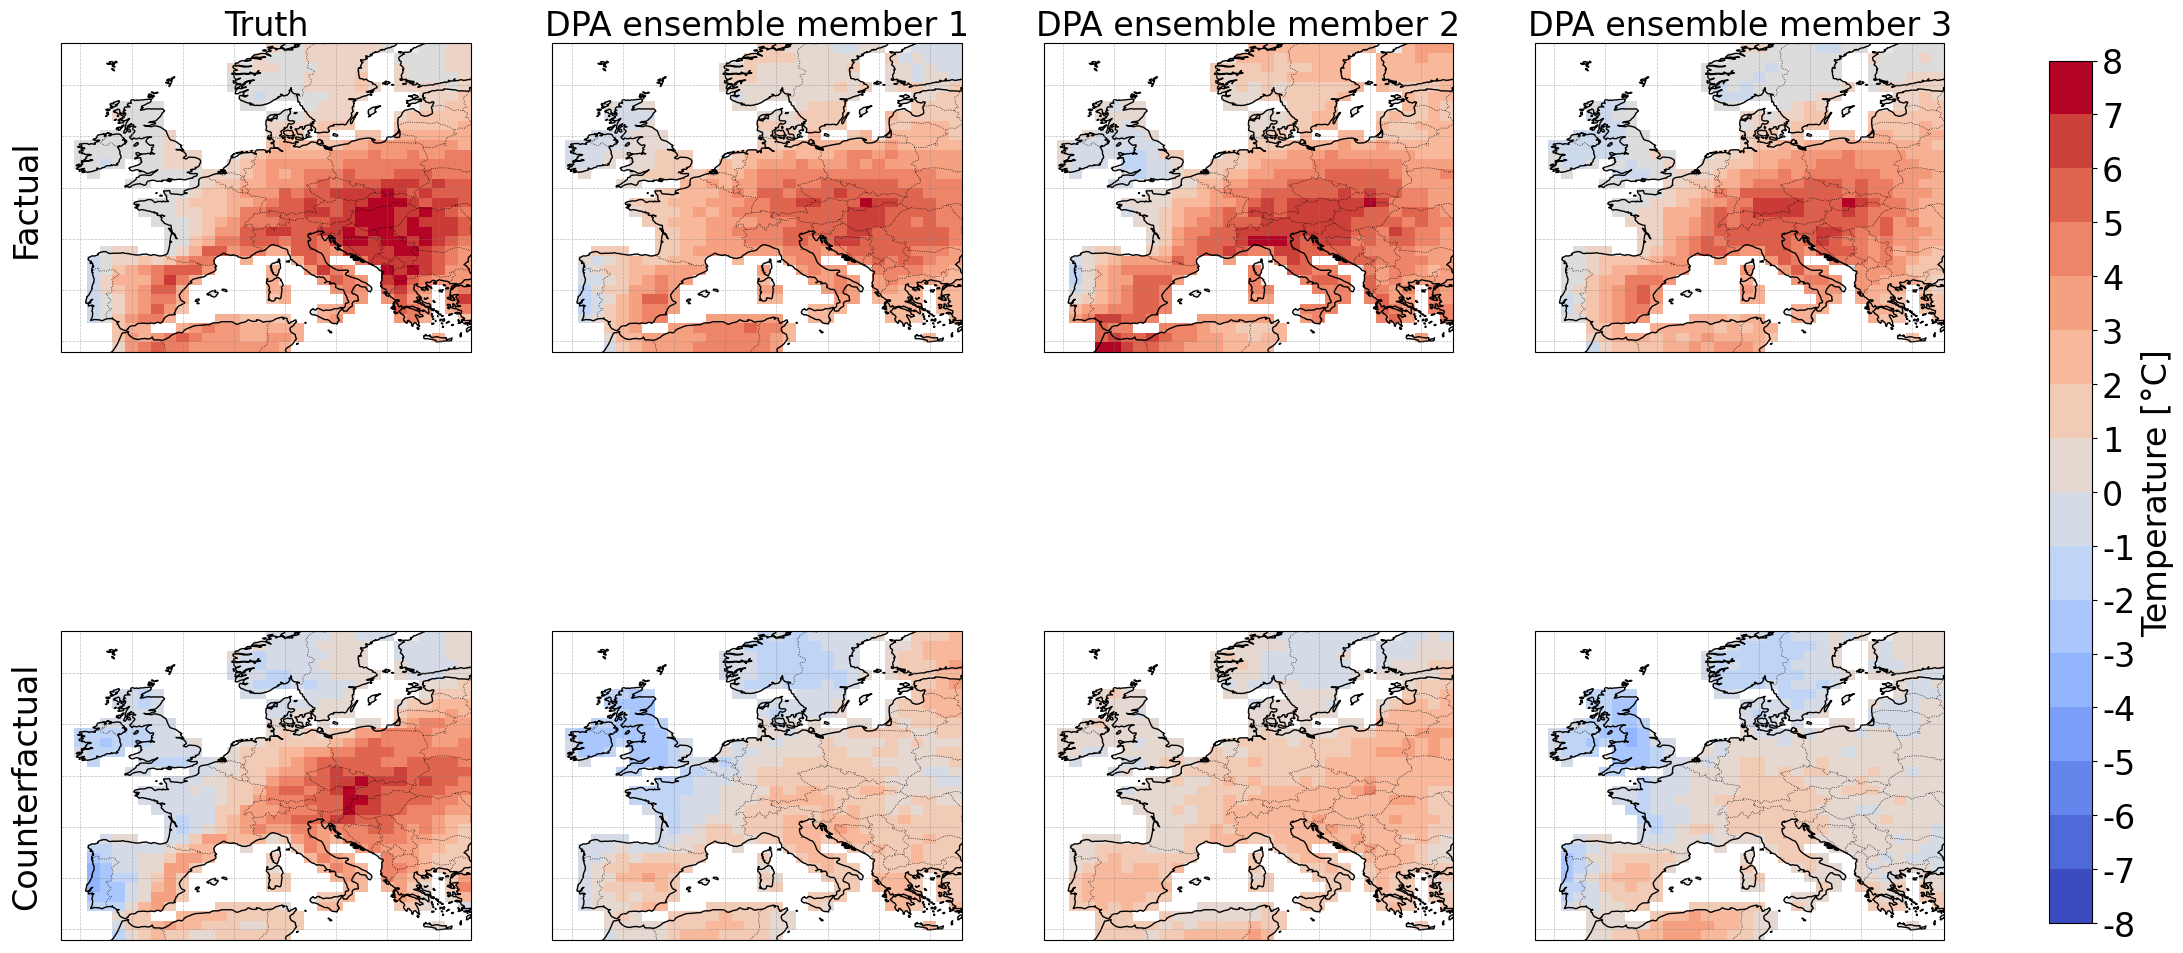

In [5]:
# both plots together

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Example dataset: ds.TREFHT should exist
date = 3620

# Factual Fields
field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
print(field_factual.time.values)
field_1 = dpa_eth_fact.TREFHT.isel(ensemble_member = 0, time=date)
field_2 = dpa_eth_fact.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_fact.TREFHT.isel(ensemble_member = 2, time=date)

# Counterfactual Fields
field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 0, time=date)
field_2_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 1, time=date)
field_3_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-8,8,17)
cmap = "coolwarm"

# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(27, 14)
)

titles = ["Truth", "DPA ensemble member 1", "DPA ensemble member 2", "DPA ensemble member 3", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=24)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='vertical', fraction=0.05, pad=0.05, shrink=0.8)
cbar.set_label('Temperature [°C]', fontsize=24)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
#plt.show()


# colorbar
# Label and tick styling
#cbar.set_label('Temperature [°C]', fontsize=14)

# Set tick positions
cbar.set_ticks(np.linspace(-8,8,17))

# Option 1: Automatically formatted numeric tick labels
cbar.set_ticklabels(range(-8,9,1), fontsize = 24)  # 1 decimal precision

# annotate
#axes[0].text(0.05, 0.95, "Factual", transform=axes[0].transAxes, 
#                fontsize=16, verticalalignment='top', 
#bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=24, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual', transform=axes[4].transAxes,
              fontsize=24, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Font size and spacing
#cbar.ax.tick_params(labelsize=10)
#plt.savefig("dpa_field_samples.pdf")


In [6]:
# compute domain average temperature
#dpa_eth_ens_spatial_mean = dpa_eth_fact.TREFHT.mean(dim=("lat","lon"))
#dpa_eth_ens_spatial_mean_cf = dpa_eth_cf.TREFHT.mean(dim=("lat","lon"))


#dpa_eth_ens_spatial_mean

In [17]:
dpa_eth_ens_spatial_mean.isel(time=date).min(dim="ensemble_member", keep_attrs=True)
print(dpa_eth_ens_spatial_mean)
# Index (integer position) of minimum ensemble member
imin = (
    dpa_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax = (
    dpa_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

# Value of the minimum
ens_min_value = (
    dpa_eth_ens_spatial_mean
    .isel(time=date)
    .isel(ensemble_member=imin)
)

# Ensemble member coordinate of the minimum
ens_min_member = ens_min_value.ensemble_member
ens_min_value
print(imin)
print(imax)


<xarray.DataArray 'TREFHT' (ensemble_member: 100, time: 14307)> Size: 6MB
array([[-1.9151069, -1.2838463, -1.0610063, ...,  5.2348995,  7.105096 ,
         5.898525 ],
       [-1.8372198, -0.7754744, -1.8727232, ...,  4.771949 ,  6.11565  ,
         4.8555794],
       [-2.092591 , -0.816533 , -2.3763382, ...,  5.248071 ,  6.969126 ,
         5.7982116],
       ...,
       [-2.1127915, -1.3987532, -1.3321136, ...,  5.1136913,  7.045753 ,
         4.762964 ],
       [-2.073583 , -1.718542 , -1.9425983, ...,  5.983696 ,  7.4633765,
         5.9595633],
       [-2.2097638, -1.0827239, -1.1553055, ...,  4.8326726,  7.1071177,
         5.2362423]], shape=(100, 14307), dtype=float32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
<xarray.DataArray 'TREFHT' ()> Size: 8B
array(19)
Coordinates:
    time     object 8B 2040-07-22 00:00:00
<xarray.DataArray 'TREFHT' ()> Siz

In [5]:
date = 3539 #=2036-06-27
#3659 = 2042-07-27 
#3620 #=year 2040 #3600 looks good
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

Date: 2036-06-27 00:00:00


Date: 2036-06-27 00:00:00


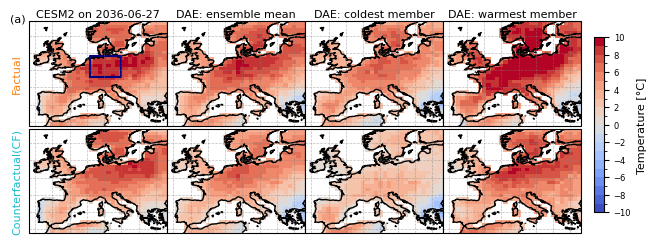

In [26]:
# both plots together including means
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np



fact_dpa_mean = dpa_eth_fact.TREFHT.mean(dim="ensemble_member")
fact_dpa_mean

cf_dpa_mean = dpa_eth_cf.TREFHT.mean(dim="ensemble_member")

# Example dataset: ds.TREFHT should exist
date = 3539 #3659#3620 #=year 2040 #3600 looks good
date_text = "2036-06-27"
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields

# find min and max values of domain average temperature
imin_fact = (
    dpa_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_fact = (
    dpa_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dpa_mean.isel(time=date)
field_2 = dpa_eth_fact.TREFHT.isel(ensemble_member = imin_fact, time=date)
field_3 = dpa_eth_fact.TREFHT.isel(ensemble_member = imax_fact, time=date)

# Counterfactual Fields

# find min and max values of domain average temperature
imin_cf = (
    dpa_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_cf = (
    dpa_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dpa_mean.isel(time=date)
field_2_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = imin_cf, time=date)
field_3_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = imax_cf, time=date)

# Plot parameters
vmin = -10
vmax = 10
no_levels=21
levels = np.linspace(-10,10,no_levels)
cmap = "coolwarm"

text_fs = 8

ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15


# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(6.5,2.5)#(14, 6)
)


titles = [f"CESM2 on {date_text}", "DAE: ensemble mean", "DAE: coldest member", "DAE: warmest member", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    

    if ax == axes[0]:
        lons = [ger_lon_min, ger_lon_max, ger_lon_max, ger_lon_min, ger_lon_min]
        lats = [ger_lat_min, ger_lat_min, ger_lat_max, ger_lat_max, ger_lat_min]
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="navy",
            linewidth=1.5,
            linestyle="-"
        )
    ax.coastlines(resolution="50m", linewidth=1)
    #ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=text_fs, pad=3)

# Add a shared colorbar
#cbar = fig.colorbar(pc, ax=axes, orientation='vertical', fraction=0.02, pad=0.1, shrink=0.8)
#cbar.set_label('Temperature [°C]', fontsize=text_fs)
#cbar.set_ticks(levels)
#cbar.ax.tick_params(labelsize=6)


###
# tighten the grid (no whitespace)
fig.subplots_adjust(left=0.03, right=0.88, bottom=0.06, top=0.92,
                    wspace=0.0, hspace=0.0)

# create a dedicated axis for the colorbar: [left, bottom, width, height]
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])

cbar = fig.colorbar(pc, cax=cax, orientation="vertical")
cbar.set_label("Temperature [°C]", fontsize=text_fs)
cbar.set_ticks(levels)
#cbar.set_ticklabels(range(-7, 8, 1))
cbar.ax.tick_params(labelsize=6)

###




# colorbar
# Label and tick styling
#cbar.set_label('Temperature [°C]', fontsize=14)

# Set tick positions
cbar.set_ticks(np.linspace(-10,10,11))

# Option 1: Automatically formatted numeric tick labels
#cbar.set_ticklabels(range(-10,11,1))  # 1 decimal precision

# annotate
#axes[0].text(0.05, 0.95, "Factual", transform=axes[0].transAxes, 
#                fontsize=16, verticalalignment='top', 
#bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))


axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=text_fs, rotation=90, color="tab:orange", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual(CF)', transform=axes[4].transAxes,
              fontsize=text_fs, rotation=90, color="tab:cyan", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[0].text(-0.135,1,"(a)", transform=axes[0].transAxes, fontsize=text_fs)
# Font size and spacing
#cbar.ax.tick_params(labelsize=10)
# tighten subplots but reserve a right margin for the colorbar

fig.subplots_adjust(wspace=0.0, hspace=0.0)
#plt.show()
plt.savefig(f"dpa_field_sample_{date_text}.pdf")


Date: 2040-07-22 00:00:00


Text(-0.125, 0.5, 'Counterfactual')

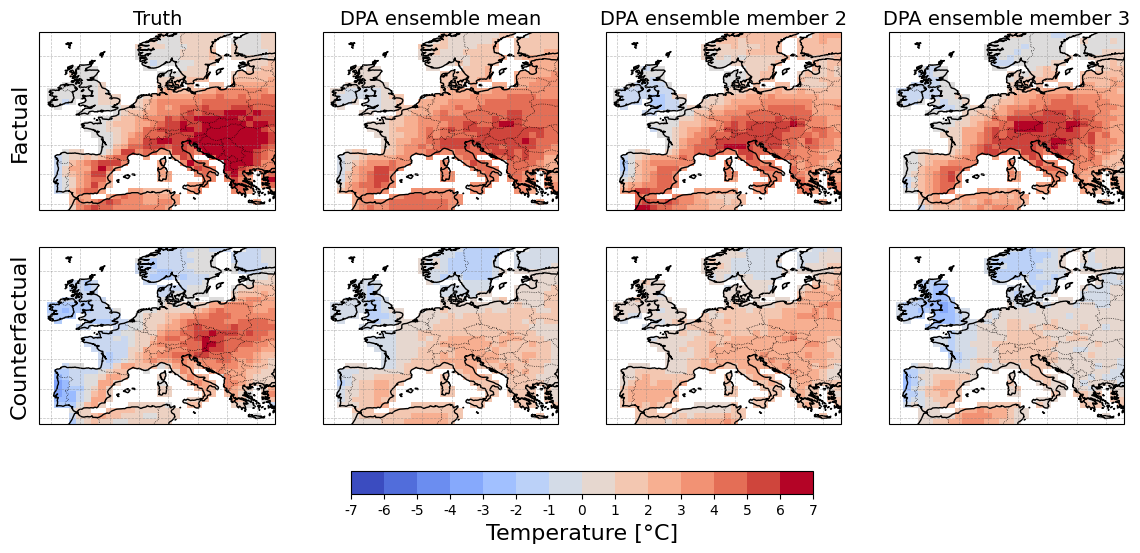

In [12]:
# both plots together including means

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


fact_dpa_mean = dpa_eth_fact.TREFHT.mean(dim="ensemble_member")
fact_dpa_mean

cf_dpa_mean = dpa_eth_cf.TREFHT.mean(dim="ensemble_member")

# Example dataset: ds.TREFHT should exist
date = 3620 #3600 looks good
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields
field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dpa_mean.isel(time=date)
field_2 = dpa_eth_fact.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_fact.TREFHT.isel(ensemble_member = 2, time=date)

# Counterfactual Fields
field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dpa_mean.isel(time=date)
field_2_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 1, time=date)
field_3_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-7,7,15)
cmap = "coolwarm"



# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(14, 6)
)

titles = ["Truth", "DPA ensemble mean", "DPA ensemble member 2", "DPA ensemble member 3", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=14)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Temperature [°C]', fontsize=16)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
#plt.show()


# colorbar
# Label and tick styling
#cbar.set_label('Temperature [°C]', fontsize=14)

# Set tick positions
cbar.set_ticks(np.linspace(-7,7,15))

# Option 1: Automatically formatted numeric tick labels
cbar.set_ticklabels(range(-7,8,1))  # 1 decimal precision

# annotate
#axes[0].text(0.05, 0.95, "Factual", transform=axes[0].transAxes, 
#                fontsize=16, verticalalignment='top', 
#bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=16, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual', transform=axes[4].transAxes,
              fontsize=16, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Font size and spacing
#cbar.ax.tick_params(labelsize=10)
#plt.savefig("dpa_sample.pdf")


## Timeseries

(4769,)
dpa_ens_ger_1300: (4769, 100)
dpa_ens_mean_ger: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-6.69371276, -3.90142378, -2.35518172, ...,  7.62937084,
        2.44451831,  7.73070776], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
lower env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-4.9428061 , -1.76000815, -0.53629497, ..., 10.08035572,
        4.51982869, 10.03409229], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
upper env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-8.44461942, -6.04283941, -4.17406847, ...,  5.17838595,
        0.36920793,  5.42732323], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00


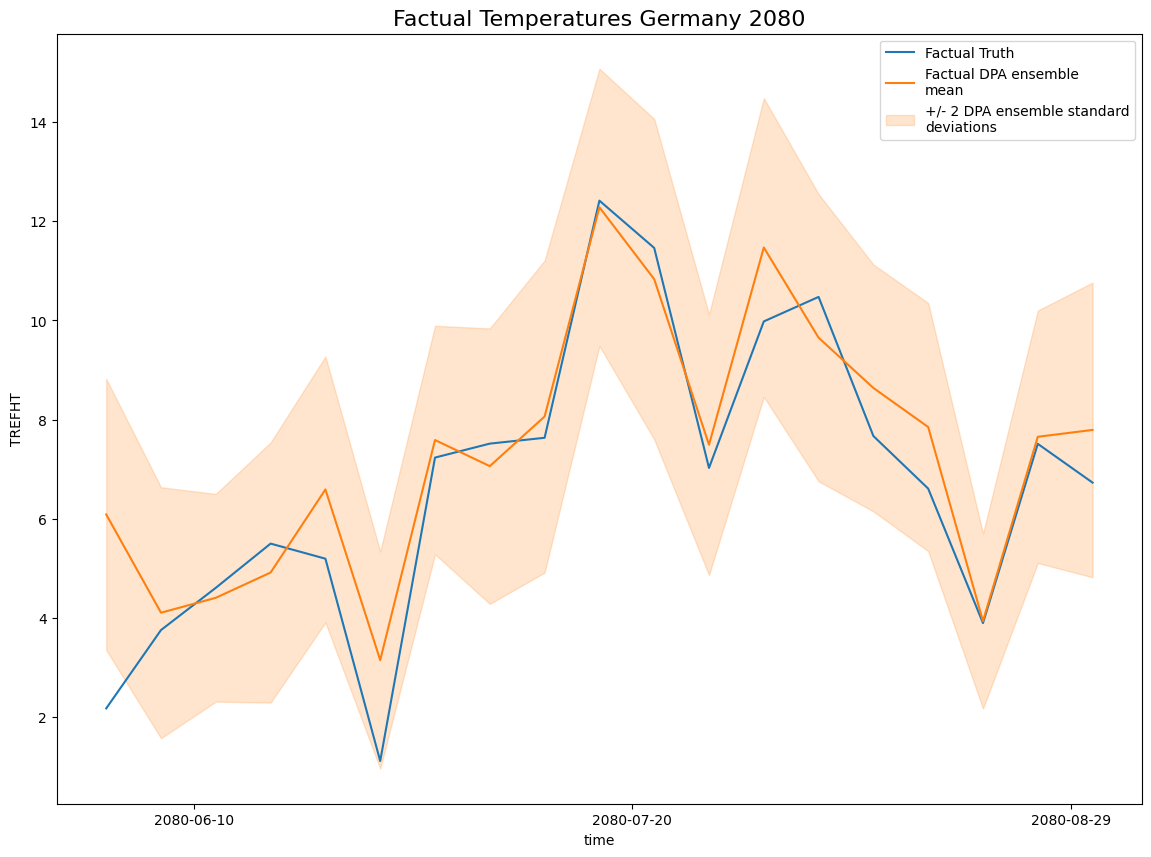

In [9]:
###################
### Time Series ###
###################


# Germany
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

year = "2080"

### Factual ###
fig, ax = evaluation.plot_dpa_time_series(true_t = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dpa_eth_fact.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = fact_dpa_mean.isel(time=slice(0,4769)),  
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = year,
                                          figsize_ts = (14,10),
                                          title_fontsize = 16,
                                          title = f"Factual Temperatures Germany {year}", 
                                          climate = "Factual"
                                          )        
#fig.savefig(f"{save_path_eth}/Germany/Germany_mean_fact_T_ts_{year}.png")
plt.show()



(4769,)
dpa_ens_ger_1300: (4769, 100)

dpa_ens_mean_ger: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-6.66656119, -3.9213839 , -2.25447718, ..., -0.16762371,
       -3.72579964, -0.72728059], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
lower env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-4.7186679 , -1.49156437, -0.09972823, ...,  1.86402382,
       -1.51063839,  1.41833752], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
upper env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-8.61445448, -6.35120344, -4.40922614, ..., -2.19927124,
       -5.94096088, -2.8728987 ], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00


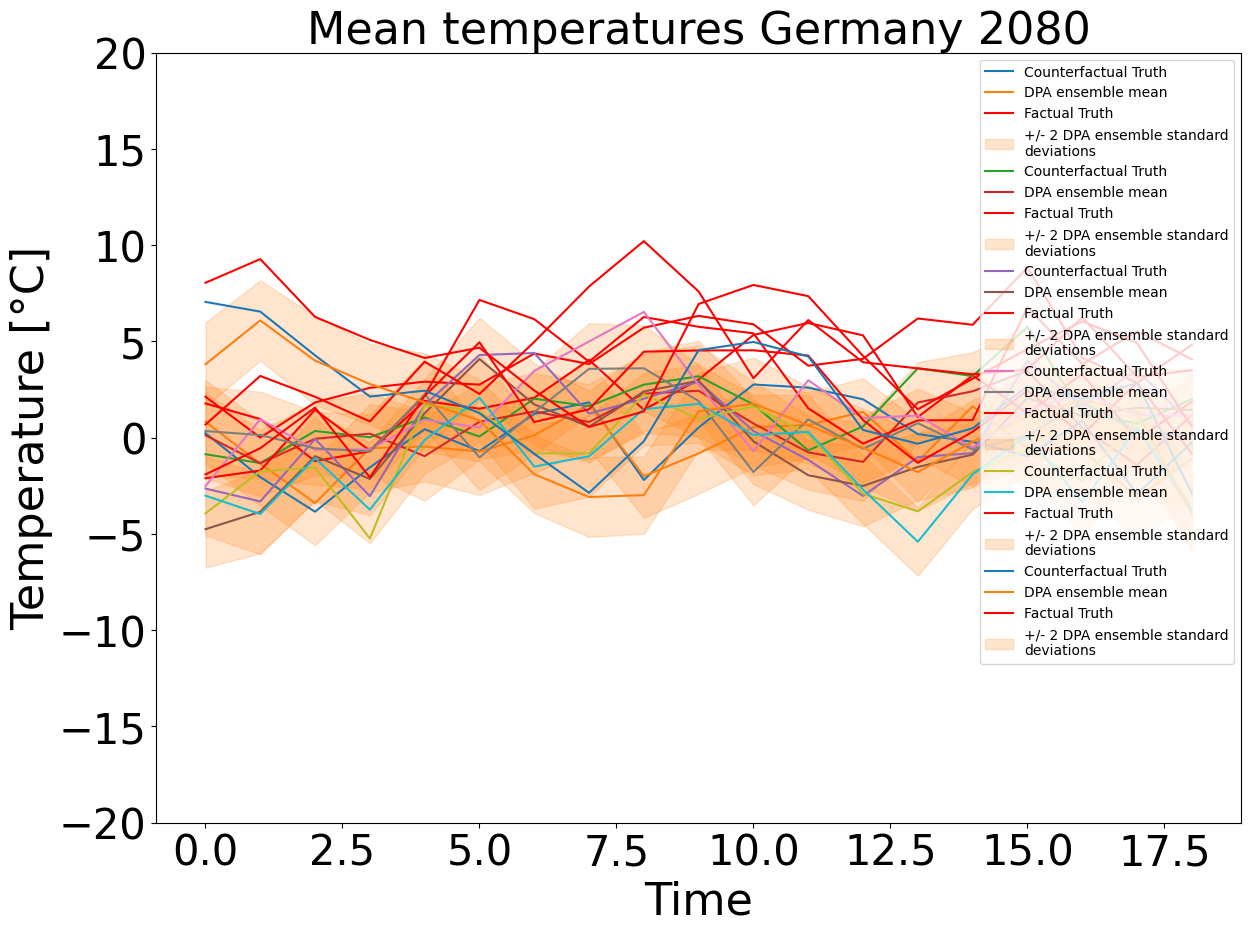

In [18]:
import importlib
importlib.reload(evaluation)

### Factual ###
fig, ax = evaluation.plot_multiple_dpa_time_series(true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dpa_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = cf_dpa_mean.isel(time=slice(0,4769)),  
                                          true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)),
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = ["2045", "2046", "2047", "2048", "2049", "2050"],
                                          figsize_ts = (14,10),
                                          title_fontsize = 16,
                                          title = f"Factual Temperatures Germany {year}", 
                                          climate = "Counterfactual"
                                          )
#fig.savefig(f"{save_path_eth}/Germany/Germany_mean_fact_T_ts_{year}.png")

### add factual time series ###
temp_true_ger_pre = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_ger_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_ger_pre['lat']}, dims=['lat'])

temp_true_ger = temp_true_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
#temp_true_ger.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).plot(ax=ax, label=f"Factual Truth", color = "tomato")
#ax.plot(np.arange(19), temp_true_ger.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).values, label=f"Factual Truth")


#dpa_ens_std = dpa_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
#dpa_ens_std_ger = dpa_ens_std.weighted(w_da_ger).mean(dim=('lat', 'lon'))
ax.set_ylabel("Temperature [°C]", fontsize = 32)
ax.set_xlabel("Time", fontsize = 32)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.ylim(-20,20)
# title
plt.title("Mean temperatures Germany 2080", fontsize=32)
plt.legend()
#plt.savefig("example_dpa_time_series.pdf")
plt.show()

In [30]:
dpa_ens_mean = cf_dpa_mean.isel(time=slice(0,4769))
dpa_ens_mean.sel(time="2042")

<xarray.DataArray 'TREFHT' (time: 19, lat: 32, lon: 32)> Size: 78kB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ..., 1.1536808 ,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ..., 0.25442207,
         0.8050029 , 1.3345217 ],
        [       nan,        nan,        nan, ..., 0.5724574 ,
         1.0227745 , 1.1424366 ],
        [       nan,        nan,        nan, ..., 0.8054671 ,
         1.0377611 , 1.5069734 ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ..., 1.6235815 ,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ..., 2.7339487 ,
         3.1168933 , 3.3405988 ],
        [       nan,        nan,        nan, ..., 2.4800339 ,
         2.6125813 , 2.757701  ],
        [       nan,        nan,        nan, ..., 2.0819242 ,
         2.3312612 , 2.6534579 ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ..., 1.108852  ,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ..., 1.4566759 ,
         1.7946496 , 1.9328716 ],
        [       nan,        nan,        nan, ..., 1.5259299 ,
         1.6032586 , 1.6981567 ],
        [       nan,        nan,        nan, ..., 1.454034  ,
         1.6485534 , 1.8498279 ]]], shape=(19, 32, 32), dtype=float32)
Coordinates:
  * time     (time) object 152B 2042-06-02 00:00:00 ... 2042-08-31 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5

In [28]:
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769))
true_t.sel(time="2042")

<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, time: 19)> Size: 78kB
[19456 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 152B 2042-06-02 00:00:00 ... 2042-08-31 00:00:00

(4769,)
dpa_ens_ger_1300: (4769, 100)
dpa_ens_mean_ger: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-6.66656119, -3.9213839 , -2.25447718, ..., -0.16762371,
       -3.72579964, -0.72728059], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
lower env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-4.7186679 , -1.49156437, -0.09972823, ...,  1.86402382,
       -1.51063839,  1.41833752], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
upper env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-8.61445448, -6.35120344, -4.40922614, ..., -2.19927124,
       -5.94096088, -2.8728987 ], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
time coordinates: [cftime.DatetimeNoLeap(2036, 6, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 7, 0, 0, 0, 0, has_year_zero=True)
 cftime.

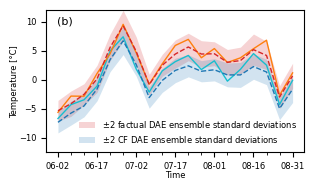

In [52]:
import importlib
importlib.reload(evaluation)

### Factual ###
year_tp = 2036
fig, ax = evaluation.plot_multiple_dpa_time_series(true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dpa_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = cf_dpa_mean.isel(time=slice(0,4769)),  
                                          true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)),
                                          dpa_ens_fact = dpa_eth_fact.isel(time=slice(0,4769)),
                                          dpa_ens_mean_fact = fact_dpa_mean.isel(time=slice(0,4769)),
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = [str(year_tp)],
                                          figsize_ts = (3.25,2),
                                          title_fontsize = 6,
                                          title = f"Factual Temperatures Germany {year_tp}", 
                                          climate = "Counterfactual"
                                          )
#fig.savefig(f"{save_path_eth}/Germany/Germany_mean_fact_T_ts_{year}.png")

### add factual time series ###
temp_true_ger_pre = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_ger_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_ger_pre['lat']}, dims=['lat'])

temp_true_ger = temp_true_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
#temp_true_ger.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).plot(ax=ax, label=f"Factual Truth", color = "tomato")
#ax.plot(np.arange(19), temp_true_ger.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).values, label=f"Factual Truth")


#dpa_ens_std = dpa_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
#dpa_ens_std_ger = dpa_ens_std.weighted(w_da_ger).mean(dim=('lat', 'lon'))
ax.set_ylabel("Temperature [°C]", fontsize = 6, labelpad=0)
ax.set_xlabel("Time", fontsize=6, labelpad=0)
ax.text(0.04,0.9,"(b)", transform=ax.transAxes, fontsize=text_fs)
plt.tick_params(axis='both', which='major', labelsize=6)
plt.ylim(-12.5,12)
plt.tight_layout()

# title
#plt.title(f"Mean temperatures Germany {year_tp}", fontsize=6)
#plt.legend()
plt.savefig(f"example_dpa_time_series_{year_tp}.pdf")
plt.show()

In [16]:
dpa_ens_mean_ger = fact_dpa_mean.isel(time=slice(0,4769)).sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time="2036").weighted(w_da_ger).mean(dim=('lat', 'lon')) # before: dpa_ensemble_restored
dpa_ens_mean_ger

<xarray.DataArray 'TREFHT' (time: 19)> Size: 152B
array([-5.34347858, -4.13346969, -2.52620438,  0.14762164,  5.55765314,
        9.28591751,  4.89089417, -0.85445039,  2.48014323,  4.40895903,
        5.63369725,  4.41680791,  4.46632876,  2.99163575,  3.29352173,
        5.17309379,  4.17382068, -2.98726075,  0.65667299])
Coordinates:
  * time     (time) object 152B 2036-06-02 00:00:00 ... 2036-08-31 00:00:00

dpa_ens_ger_1300: (1, 100)
(100,)
(100,)


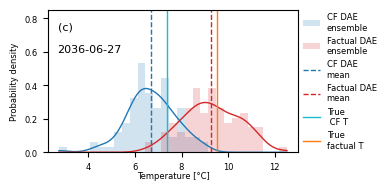

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

year = "2036"
dpa_ens = dpa_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=slice(year,year))
dpa_ens_fact = dpa_eth_fact.isel(time=slice(0,4769)).sel(time=slice(year,year))

dpa_ens_mean = cf_dpa_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))
dpa_ens_mean_fact = fact_dpa_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))


lat_min = ger_lat_min 
lat_max = ger_lat_max
lon_min = ger_lon_min 
lon_max = ger_lon_max 
date=date_text

# data
### DPA Ensemble COUNTERFACTUAL ###
# standard deviation, germany mean
#dpa_ens_std = dpa_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
#dpa_ens_std_ger = dpa_ens_std.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble mean, germany mean 
dpa_ens_mean_ger = dpa_ens_mean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon')) # before: dpa_ensemble_restored
#print(dpa_ens_mean_ger.shape)
#dpa_ens_mean_ger_cf = dpa_ens_mean_cf_1300_restored.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dpa_ens_ger_1300 = dpa_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dpa_ens_ger_1300:", dpa_ens_ger_1300.values.T.shape)

# counterfactual truth
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=date)
cf_truth_ger = true_t.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))


### DPA Ensemble FACTUAL ###
# standard deviation, germany mean
#dpa_ens_std_fact = dpa_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
#dpa_ens_std_ger_fact = dpa_ens_std_fact.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble mean, germany mean 
dpa_ens_mean_ger_fact = dpa_ens_mean_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon')) # before: dpa_ensemble_restored
#print(dpa_ens_mean_ger_fact.shape)
#dpa_ens_mean_ger_cf = dpa_ens_mean_cf_1300_restored.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dpa_ens_ger_1300_fact = dpa_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).TREFHT.weighted(w_da_ger).mean(dim=('lat', 'lon'))
#print("dpa_ens_ger_1300:", dpa_ens_ger_1300.values.T.shape)

# factual truth
true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(time=date)
fact_truth_ger = true_t_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))




# Example data (replace with your own arrays)
a = dpa_ens_ger_1300.values.flatten() #np.random.randn(1000) #dpa_ens_ger_1300.values
b = dpa_ens_ger_1300_fact.values.flatten() #np.random.randn(1000) + 1.0 # #
print(a.shape)
print(b.shape)


# Common bins
bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    30
)

fig, ax = plt.subplots(figsize=(4,2))

# Histograms (normalized)
ax.hist(
    a, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="CF DAE\nensemble", color="tab:blue", alpha=0.2
)
ax.hist(
    b, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="Factual DAE\nensemble", color="tab:red", alpha=0.2
)

# KDEs
x = np.linspace(bins[0], bins[-1], 500)
kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

ax.plot(x, kde_a(x), linewidth=1, color="tab:blue")
ax.plot(x, kde_b(x), linewidth=1, color="tab:red")



# mean values

ax.axvline(
    x=dpa_ens_mean_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:blue",
    linestyle="--",
    linewidth=1.0,
    label="CF DAE\nmean"
)

ax.axvline(
    x=dpa_ens_mean_ger_fact.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label="Factual DAE\nmean"
)



ax.axvline(
    x=cf_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    label="True\n CF T"
)

ax.axvline(
    x=fact_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:orange",
    linestyle="-",
    linewidth=1.0,
    label="True\nfactual T"
)



# Labels and legend
ax.set_xlabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_ylabel("Probability density", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.text(0.04,0.7,f"(c)\n\n{date}", transform=ax.transAxes, fontsize=text_fs)

#ax.legend(frameon=False, fontsize=6, ncol=1)

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6
)

fig.subplots_adjust(right=0.75)

#ax.set_xlim(-1,5)
ax.set_ylim(0.0, 0.85)

plt.tight_layout()
plt.savefig(f"T_distrs_{date_text}.pdf")
plt.show()


In [94]:
dpa_ens_ger_1300 = dpa_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time="2020-07-07").weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dpa_ens_ger_1300:", dpa_ens_ger_1300.values.T.shape)

dpa_ens_ger_1300: (1, 100)


In [96]:
dpa_ens_ger_1300_fact = dpa_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time="2020-07-07").weighted(w_da_ger).mean(dim=('lat', 'lon'))
dpa_ens_ger_1300_fact

<xarray.Dataset> Size: 2kB
Dimensions:          (ensemble_member: 100, time: 1)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 8B 2020-07-07 00:00:00
Data variables:
    TREFHT           (ensemble_member, time) float64 800B 2.799 3.068 ... 2.915

In [ ]:
# CORRELATION
import torch

def plot_map(field, levels, cmap="bwr", cmap_label = ""):
    
    # create plot with a map projection
    fig, ax = plt.subplots(
        subplot_kw={'projection': ccrs.PlateCarree()}, 
        figsize=(14, 10)
    )
    
    # plot the data
    field.plot(ax=ax,
               transform=ccrs.PlateCarree(),
               cmap=cmap,
               levels=levels,
               cbar_kwargs={'label': cmap_label, 'shrink': 0.7})
    
    # add coastlines and continents
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    
    # optional: gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    #plt.show()

    return fig, ax

### Counterfactual ###
######################

## turn dpa ens (mean) into torch array
dpa_ens_mean_cf_1300_raw_pt = torch.from_numpy(cf_dpa_mean.isel(time=slice(0,4769)).values) #dpa_ens_mean_pt

## turn truth array into torch array 
eth_cf_1300_test = torch.from_numpy(ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).values).permute(2, 0, 1) #dpa_ens_mean_pt

print(dpa_ens_mean_cf_1300_raw_pt.shape)
print(eth_cf_1300_test.shape)

# calculate correlation
r_cols_cf = evaluation.pearsonr_cols(eth_cf_1300_test, dpa_ens_mean_cf_1300_raw_pt, dim=0)  # shape: (648,)
print(r_cols_cf.shape)

corr_spatial_cf = ut.torch_to_dataarray(r_cols_cf, ds_test_eth_cf, name="Pearson correlation coefficient")

# plot
fig, ax = ut.plot_map(corr_spatial_cf, np.linspace(0.7, 1, 7), cmap="YlOrRd", cmap_label = "Pearson Correlation")
ax.set_title("Correlation", fontsize=18)

# Access the colorbar from the plotted DataArray (if plot_map uses xarray or plt)
cbar = ax.collections[0].colorbar  # works for xarray DataArray.plot()

# Change the colorbar label font size
cbar.set_label('Pearson Correlation', fontsize=16)

# Optionally, adjust tick label size
cbar.ax.tick_params(labelsize=14)

plt.savefig(f"cf_correlation_eth_test_figure.pdf")
plt.show()


## Min/Max temperature time series

In [14]:
####################
### Load my data ###
####################
# load my data
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

print("Top-level keys:", list(settings.keys()))

# Load LE temperature data
# Train data
trefht_le = xr.open_dataset(settings['dataset_trefht'])
print(trefht_le)

# Load LE Z500 
z500_le = xr.open_dataset(settings["dataset_z500"])
#if args.standardize_predictors:
#    predictors_combined_le, _, _ = ut.standardize_numpy(z500_le.pseudo_pcs.values) 
#else:
#    predictors_combined_le = z500_le.pseudo_pcs.values #xr.concat([gmt_le_expanded, z500_le.pseudo_pcs], dim="mode")

predictors_combined_le = z500_le.pseudo_pcs.values

print(z500_le)

# load LE GMT
#gmt_le_pre = xr.open_dataset(settings["GMT_LE"])
#gmt_le = (gmt_le_pre - gmt_le_pre.mean()) / gmt_le_pre.std()
#print(gmt_le)

# concatenate data 
#gmt_le_expanded = gmt_le.TREFHT.expand_dims(mode=[-1]).T  # add 'mode' dimension with length 1
predictors_combined_le
#gmt_le_expanded

# Load ETH ensemble data
# Test data
trefht_eth = xr.open_dataset(settings['dataset_trefht_eth_transient'])
print(trefht_eth)

z500_eth = xr.open_dataset(settings['dataset_z500_eth_test'])
print(z500_eth)

# Load GMT ETH
#gmt_eth_pre = xr.open_dataset(settings["gmt_eth"])
#gmt_eth = (gmt_eth_pre - gmt_eth_pre.mean()) / gmt_eth_pre.std()

# concatenate data 
#gmt_eth_expanded = gmt_eth.TREFHT.expand_dims(mode=[-1]).T  # add 'mode' dimension with length 1
predictors_combined_eth = z500_eth.pseudo_pcs #xr.concat([gmt_eth_expanded, z500_eth.pseudo_pcs], dim="mode")
predictors_combined_eth
# germany domain 
### Germany ###
    
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut train data
trefht_le_ger = trefht_le.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_le_ger)

# cut test data
trefht_eth_ger = trefht_eth.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_eth_ger)

# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(trefht_le_ger["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# training data
trefht_le_ger_mean = trefht_le_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_le_ger_mean

# test_data
trefht_eth_ger_mean = trefht_eth_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_eth_ger_mean

print("Predictors train shape:", predictors_combined_le.shape)
print("Predictands train shape:", trefht_le_ger_mean.shape)
print("#######")
print("Predictors train shape:", predictors_combined_eth.shape)
print("Predictands test shape:", trefht_eth_ger_mean.shape)

Top-level keys: ['output_dir', 'dataset_trefht', 'dataset_z500', 'dataset_trefht_eth_transient', 'dataset_trefht_eth_nudged_shifted', 'dataset_z500_eth_test']
<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...
<xarray.Dataset> Size: 2GB
Dimensions:     (time: 476900, mode: 1001)
Coordinates:
  * time        (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 2GB 670.0 -1.451e+03 ... -0.4472 4.744
<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.

In [15]:
trefht_eth_ger_mean
dpa_eth_cf

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB nan ... -1...

[   3   25   42   58   87  103  131  136  170  187  195  221  242  249
  268  292  317  323  359  373  388  404  435  451  458  486  512  530
  540  556  571  594  623  641  647  683  692  716  737  756  760  789
  803  817  837  866  880  897  921  934  952  972  998 1020 1038 1052
 1082 1093 1117 1137 1152 1173 1183 1209 1225 1239 1270 1276 1305 1316
 1333 1351 1372 1398 1413 1443 1462 1479 1499 1502 1537 1547 1570 1589
 1596 1618 1647 1668 1681 1706 1710 1747 1753 1778 1793 1814 1838 1859
 1869 1895 1905 1923 1945 1963 1994 2001 2017 2051 2067 2072 2107 2118
 2136 2158 2173 2192 2218 2232 2257 2270 2285 2300 2333 2344 2374 2393
 2412 2422 2432 2458 2486 2504 2515 2542 2564 2579 2601 2618 2629 2651
 2665 2688 2710 2722 2742 2766 2778 2803 2812 2838 2867 2880 2895 2925
 2943 2950 2981 2996 3020 3030 3052 3070 3087 3107 3126 3144 3163 3189
 3198 3222 3246 3265 3284 3299 3312 3342 3353 3371 3394 3408 3432 3441
 3474 3477 3511 3524 3539 3553 3583 3601 3621 3642 3659 3676 3691 3716
 3739 

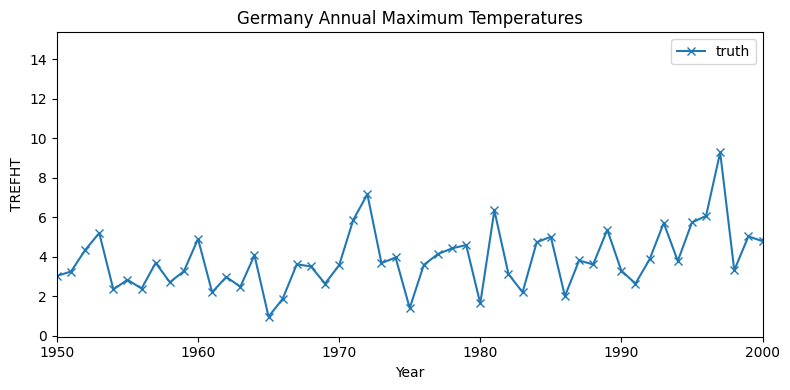

In [16]:
trefht_eth_ger_mean_1300 = trefht_eth_ger_mean.isel(time=slice(0,4769))
da_max_year_pre = trefht_eth_ger_mean_1300.groupby("time.year").max()

s = trefht_eth_ger_mean_1300.to_series()                      # pandas Series with DatetimeIndex
t_max = s.groupby(s.index.year).idxmax()

da_max_year = da_max_year_pre.assign_coords(year=(t_max.values))
da_max_year

# integer indices in the original time axis
time_index = pd.Index(trefht_eth_ger_mean_1300.time.values)
idx = time_index.get_indexer(t_max.values)
print(idx)
plt.figure(figsize=(8, 4))

plt.plot(
    da_max_year_pre.year.values,
    da_max_year.values,
    marker='x',
    label = "truth"
)

#plt.plot(
#    da_max_year_pre.year.values,
#    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx),
#    marker='x',
#    label="linear model (x: 10 PCs + GMT)"
#)

plt.xlabel("Year")
plt.ylabel(trefht_eth_ger_mean.name if trefht_eth_ger_mean.name is not None else "Value")
plt.title("Germany Annual Maximum Temperatures")

plt.xlim(1950, 2000)
plt.legend()
plt.tight_layout()

#plt.savefig("figures/vrfdynanical_adjustment_ts.pdf")
plt.show()

In [17]:
dpa_eth_fact

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB nan ... 3.871

In [18]:
### DPA Ensemble ###
# standard deviation, germany mean
dpa_ens_std = dpa_eth_fact.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
dpa_ens_std_ger = dpa_ens_std.weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769))

# ensemble mean, germany mean 
dpa_ens_mean_ger = fact_dpa_mean.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max)).weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769)) # before: dpa_ensemble_restored
print(dpa_ens_mean_ger.shape)
#dpa_ens_mean_ger_cf = dpa_ens_mean_cf_1300_restored.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dpa_ens_ger_1300 = dpa_eth_fact.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max)).weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769))
dpa_ens_ger_1300
#print("dpa_ens_ger_1300:", dpa_ens_ger_1300.values.T.shape)

(4769,)


<xarray.Dataset> Size: 4MB
Dimensions:          (ensemble_member: 100, time: 4769)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00...
Data variables:
    TREFHT           (ensemble_member, time) float64 4MB -7.767 -4.526 ... 8.711

In [19]:
dpa_ens_mean_ger

<xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-7.11830354, -4.28580704, -2.52395527, ...,  8.2063092 ,
        2.18970718,  7.62729466], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

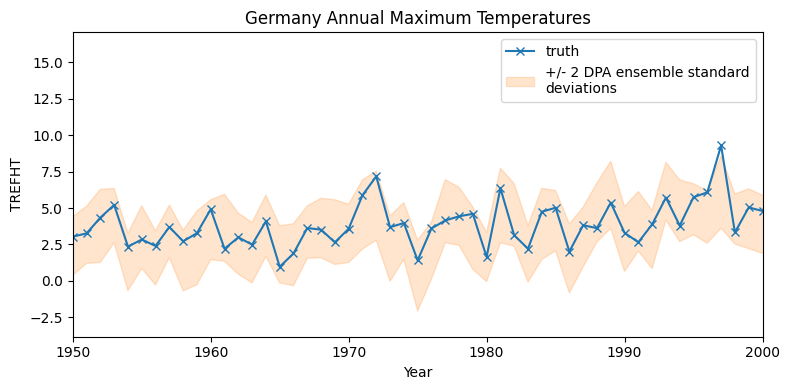

In [20]:
plt.figure(figsize=(8, 4))

plt.plot(
    da_max_year_pre.year.values,
    da_max_year.values,
    marker='x',
    label = "truth"
)

#plt.plot(
#    da_max_year_pre.year.values,
#    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx),
#    marker='x',
#    label="linear model (x: 10 PCs + GMT)"
#)

n_stds = 2
upper_env = dpa_ens_mean_ger + n_stds * dpa_ens_std_ger.TREFHT 
lower_env = dpa_ens_mean_ger - n_stds * dpa_ens_std_ger.TREFHT

#plt.plot(
#    da_max_year_pre.year.values,
#    lower_env.isel(time=idx).values
#)

#plt.plot(
#    da_max_year_pre.year.values,
#    upper_env.isel(time=idx).values
#)


# fill_between needs numpy arrays + axis
plt.fill_between(
    da_max_year_pre.year.values,   # x-axis values (datetime64)
    lower_env.isel(time=idx).values,        # lower bound
    upper_env.isel(time=idx).values,        # upper bound
    color="tab:orange", alpha=0.2, label=f"+/- {n_stds} DPA ensemble standard\ndeviations"
)

plt.xlabel("Year")
plt.ylabel(trefht_eth_ger_mean.name if trefht_eth_ger_mean.name is not None else "Value")
plt.title("Germany Annual Maximum Temperatures")

plt.xlim(1950, 2000)
plt.legend()
plt.tight_layout()

#plt.savefig("figures/vrfdynanical_adjustment_ts.pdf")
plt.show()

### Linear Model

In [21]:
# standardize predictors
###
## train
train_predictors, _, _ = ut.standardize_numpy(predictors_combined_le[:90*4769, :])
X_torch = torch.from_numpy(train_predictors)
y_torch = torch.from_numpy(trefht_le_ger_mean.values)[:90*4769]

## validation
validation_predictors, _, _ = ut.standardize_numpy(predictors_combined_le[90*4769:, :])
X_val_torch = torch.from_numpy(validation_predictors)
y_val_torch = torch.from_numpy(trefht_le_ger_mean.values)[90*4769:]

## test
test_predictors, _, _ = ut.standardize_numpy(z500_eth.pseudo_pcs.values)
x_test_torch = torch.from_numpy(test_predictors)

print("X:", X_torch.shape)
print("y:", y_torch.shape)

print("X_val:", X_val_torch.shape)
print("y_val:", y_val_torch.shape)

print("X test:", x_test_torch.shape)

# fit linear model

#X = X_torch[:4769, :10].float()
X = torch.cat(
    [X_torch[:, :20], X_torch[:, -1:].clone()],
    dim=1
)
y = y_torch[:].float()


print(X.shape)
# Add bias column
X_aug = torch.cat([X, torch.ones(X.shape[0], 1)], dim=1)

# Solve min ||X w - y||
w = torch.linalg.lstsq(X_aug, y).solution

weights = w[:-1]
bias = w[-1]


# apply model to test data
test_predictors = torch.cat(
    [x_test_torch[:, :20], x_test_torch[:, -1:].clone()],
    dim=1
)
#y_pred_test = x_test_torch[:,:10].float() @ weights + bias
y_pred_test = test_predictors.float() @ weights + bias
print(type(y_pred_test))
# evaluation
mse = torch.mean((y_pred_test - torch.from_numpy(trefht_eth_ger_mean.values)) ** 2)
rmse = torch.sqrt(mse)
print("Test RMSE:", rmse.item())

# create xarray from predictions

y_pred_test_xr = xr.DataArray(y_pred_test.detach().numpy(),
                              dims = ["time"],
                              coords = {"time": trefht_eth_ger_mean.time},
                              name="TREFHT")
y_pred_test_xr.isel(time=slice(0,4769))

X: torch.Size([429210, 1001])
y: torch.Size([429210])
X_val: torch.Size([47690, 1001])
y_val: torch.Size([47690])
X test: torch.Size([14307, 1001])
torch.Size([429210, 21])
<class 'torch.Tensor'>
Test RMSE: 1.3490069593402736


<xarray.DataArray 'TREFHT' (time: 4769)> Size: 19kB
array([-6.6413145, -3.348659 , -2.888764 , ...,  5.9868145,  3.212593 ,
        5.9089346], shape=(4769,), dtype=float32)
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

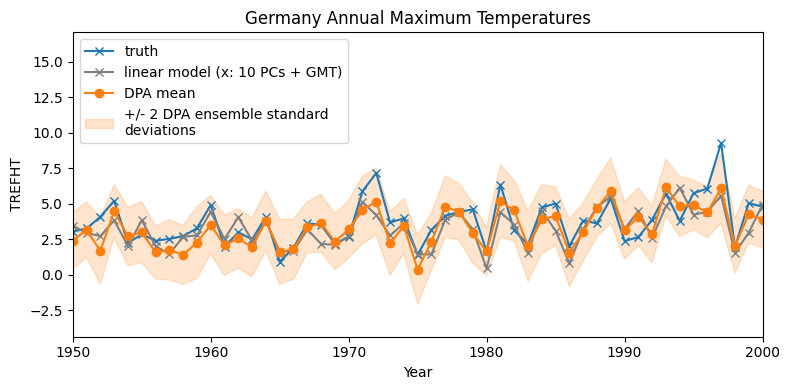

In [25]:
idx_abs = np.load("yearly_absolute_max_indices_ger.npy")

plt.figure(figsize=(8, 4))

# plot true temperature anomalies 
plt.plot(
    da_max_year_pre.year.values,
    trefht_eth_ger_mean_1300.values[idx_abs], #da_max_year.values[idx_abs],
    marker='x',
    label = "truth"
)

# plot linear model
plt.plot(
    da_max_year_pre.year.values,
    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs).values,
    marker='x',
    color="grey",
    label="linear model (x: 10 PCs + GMT)"
)


# plot DPA ensemble mean
plt.plot(
    da_max_year_pre.year.values,
    dpa_ens_mean_ger.isel(time=idx_abs).values,
    marker='o',
    label = "DPA mean"
)

#plt.plot(
#    da_max_year_pre.year.values,
#    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs),
#    marker='x',
#    label="linear model (x: 10 PCs + GMT)"
#)

n_stds = 2
upper_env = dpa_ens_mean_ger + n_stds * dpa_ens_std_ger.TREFHT 
lower_env = dpa_ens_mean_ger - n_stds * dpa_ens_std_ger.TREFHT

#plt.plot(
#    da_max_year_pre.year.values,
#    lower_env.isel(time=idx_abs).values
#)

#plt.plot(
#    da_max_year_pre.year.values,
#    upper_env.isel(time=idx_abs).values
#)



# fill_between needs numpy arrays + axis
plt.fill_between(
    da_max_year_pre.year.values,   # x-axis values (datetime64)
    lower_env.isel(time=idx_abs).values,        # lower bound
    upper_env.isel(time=idx_abs).values,        # upper bound
    color="tab:orange", alpha=0.2, label=f"+/- {n_stds} DPA ensemble standard\ndeviations"
)

plt.xlabel("Year")
plt.ylabel(trefht_eth_ger_mean.name if trefht_eth_ger_mean.name is not None else "Value")
plt.title("Germany Annual Maximum Temperatures")

plt.xlim(1950, 2000)
plt.legend()
plt.tight_layout()

#plt.savefig("figures/DPA_dynamical_adjustment_ts.pdf")
plt.show()

In [23]:
import numpy as np

corr_dpa_mean = np.corrcoef(da_max_year.values[100:150], dpa_ens_mean_ger.isel(time=idx).values[100:150])[0, 1]
print(corr_dpa_mean)

corr_linearmodel_mean = np.corrcoef(da_max_year.values[100:150], y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx).values[100:150])[0, 1]
print(corr_linearmodel_mean)

0.7941886244662433
0.6648456789104774


In [70]:
da_max_year.values.shape

(251,)

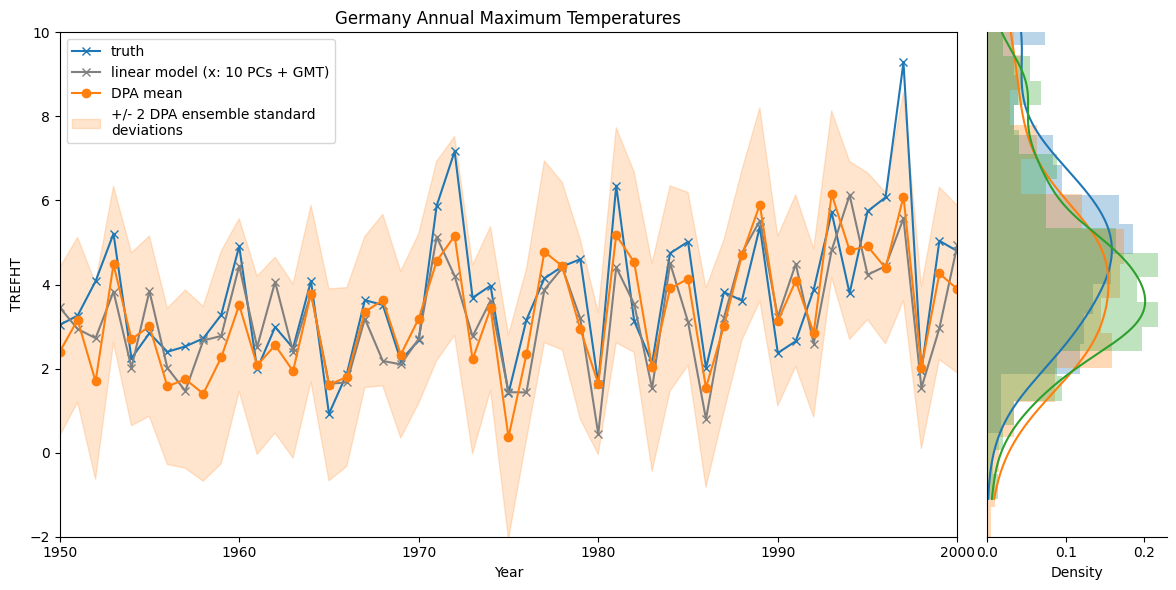

In [50]:
# add distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 6))

# --- main time series ---

# plot true temperature anomalies 
plt.plot(
    da_max_year_pre.year.values,
    trefht_eth_ger_mean_1300.values[idx_abs], #da_max_year.values[idx_abs],
    marker='x',
    label = "truth"
)

# plot linear model
plt.plot(
    da_max_year_pre.year.values,
    y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs).values,
    marker='x',
    color="grey",
    label="linear model (x: 10 PCs + GMT)"
)


# plot DPA ensemble mean
plt.plot(
    da_max_year_pre.year.values,
    dpa_ens_mean_ger.isel(time=idx_abs).values,
    marker='o',
    label = "DPA mean"
)
# fill_between
plt.fill_between(
    da_max_year_pre.year.values,   # x-axis values (datetime64)
    lower_env.isel(time=idx_abs).values,        # lower bound
    upper_env.isel(time=idx_abs).values,        # upper bound
    color="tab:orange", alpha=0.2, label=f"+/- {n_stds} DPA ensemble standard\ndeviations"
)


# quantile predictions with quantile interval (0.05-0.95)
#ax.plot(da_max_year_pre.year.values, quantile_predictions[0:4769,9][idx_abs], label = 'quantile regression:\npredicted median', color='k')
#ax.fill_between(
#    da_max_year_pre.year.values,   # x-axis values (datetime64)
#    quantile_predictions[0:4769,0][idx_abs],        # lower bound
#    quantile_predictions[0:4769,18][idx_abs],        # upper bound
#    color="grey", alpha=0.2, label=f"quantile regression:\n0.05 - 0.95 quantile range"
#)

ax.set_xlabel("Year")
ax.set_ylabel(trefht_eth_ger_mean.name or "Value")
ax.set_title("Germany Annual Maximum Temperatures")
ax.set_xlim(1950, 2000)
ax.legend(loc="upper left")

# --- create a separate marginal axis on the RIGHT ---
divider = make_axes_locatable(ax)
#ax_dist = divider.append_axes("right", size="20%", pad=0.1, sharey=ax)

divider = make_axes_locatable(ax)
ax_dist = divider.append_axes(
    "right",
    size="20%",
    pad=0.3,   # ← increase this value to add more space
    sharey=ax
)

# --- data ---
truth_vals = trefht_eth_ger_mean_1300.values[idx_abs] #da_max_year.values
model_vals = y_pred_test_xr.isel(time=slice(0,4769)).isel(time=idx_abs).values #linear model
dpa_vals = dpa_ens_ger_mean.TREFHT.values[0,idx_abs].flatten() # plot one ensemble member or all 100 members


y_grid = np.linspace(
    min(truth_vals.min(), model_vals.min()),
    max(truth_vals.max(), model_vals.max()),
    400
)

# KDEs
truth_kde = gaussian_kde(truth_vals)
dpa_kde = gaussian_kde(dpa_vals)
model_kde = gaussian_kde(model_vals)

# Histograms (horizontal)
ax_dist.hist(
    truth_vals,
    bins=20,
    orientation="horizontal",
    density=True,
    alpha=0.3,
    color="tab:blue"
)

ax_dist.hist(
    dpa_vals,
    bins=20,
    orientation="horizontal",
    density=True,
    alpha=0.3,
    color="tab:orange"
)

ax_dist.hist(
    model_vals,
    bins=20,
    orientation="horizontal",
    density=True,
    alpha=0.3,
    color="tab:green"
)

# KDE lines
ax_dist.plot(truth_kde(y_grid), y_grid, color="tab:blue")
ax_dist.plot(dpa_kde(y_grid), y_grid, color="tab:orange")
ax_dist.plot(model_kde(y_grid), y_grid, color="tab:green")


# --- styling: marginal only ---
ax_dist.set_xlabel("Density")
ax_dist.yaxis.set_visible(False)
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)

plt.tight_layout()
plt.ylim(-2,10)
plt.show()


In [30]:
dpa_ens_ger = dpa_eth_fact.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
dpa_ens_ger_mean = dpa_ens_ger.weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769))
dpa_ens_ger_mean

<xarray.Dataset> Size: 4MB
Dimensions:          (ensemble_member: 100, time: 4769)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00...
Data variables:
    TREFHT           (ensemble_member, time) float64 4MB -7.767 -4.526 ... 8.711

In [45]:
dpa_ens_ger_mean.TREFHT.values.flatten().shape

(476900,)

In [49]:
print(np.mean(truth_vals))
print(np.mean(dpa_vals))
print(np.mean(model_vals))

5.811037572731535
4.978284843828468
4.4249225


In [41]:
dpa_ens_ger_mean.TREFHT.values[:,idx_abs].shape

(100, 251)

In [6]:
import numpy as np
print(np.arange(1850,2101))

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 